In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset .csv to Dataset .csv


In [2]:
import pandas as pd
df=pd.read_csv("Dataset .csv")

In [3]:
print(df.columns.tolist())

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [4]:
print(df['Rating text'].unique())

['Excellent' 'Very Good' 'Good' 'Average' 'Not rated' 'Poor']


In [5]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [6]:
# Count the frequency of each rating text
rating_text_count = df['Rating text'].value_counts()

# Display the result
print("Rating Text Distribution:")
print(rating_text_count)

Rating Text Distribution:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


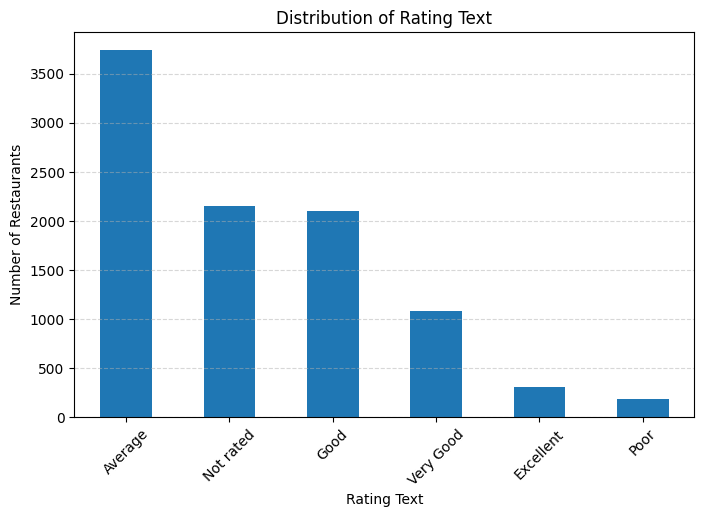

In [7]:
import matplotlib.pyplot as plt

# Create a bar chart of rating text distribution
plt.figure(figsize=(8,5))

rating_text_count.plot(kind='bar')

plt.title("++)
plt.xlabel("Rating Text")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [8]:
# Define positive and negative categories
positive = ['Excellent', 'Very Good', 'Good']
negative = ['Average', 'Poor', 'Not rated']

positive_count = df[df['Rating text'].isin(positive)].shape[0]
negative_count = df[df['Rating text'].isin(negative)].shape[0]

print("Positive Ratings:", positive_count)
print("Negative Ratings:", negative_count)

Positive Ratings: 3480
Negative Ratings: 6071


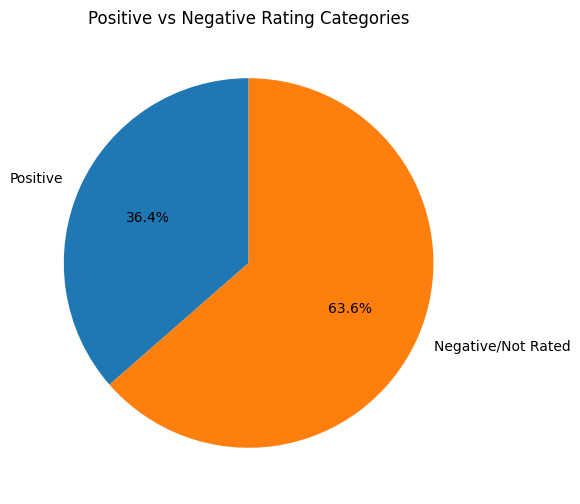

In [9]:
plt.figure(figsize=(6,6))

plt.pie(
    [positive_count, negative_count],
    labels=['Positive', 'Negative/Not Rated'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Positive vs Negative Rating Categories")

plt.show()

## Dataset Limitation

The provided dataset does not contain textual customer reviews. Therefore, analysis such as keyword extraction, review length calculation, and review length versus rating could not be performed.

Instead, the available "Rating text" column was analyzed to understand customer sentiment categories.

**Level 3 task 2**

In [10]:
#the restaurant with the highest number of votes
highest_votes = df.loc[df['Votes'].idxmax()]

# Display restaurant details
print("Restaurant with Highest Votes:")
print(highest_votes[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

Restaurant with Highest Votes:
Restaurant Name          Toit
City                Bangalore
Votes                   10934
Aggregate rating          4.8
Name: 728, dtype: object


In [11]:
#the restaurant with the lowest number of votes
lowest_votes = df.loc[df['Votes'].idxmin()]

# Display restaurant details
print("Restaurant with Lowest Votes:")
print(lowest_votes[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

Restaurant with Lowest Votes:
Restaurant Name     Cantinho da Gula
City                      S��o Paulo
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object


In [12]:
# Find the minimum number of votes
min_votes = df['Votes'].min()

# Display all restaurants with the minimum votes
lowest_vote_restaurants = df[df['Votes'] == min_votes]

print(lowest_vote_restaurants[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

                 Restaurant Name        City  Votes  Aggregate rating
69              Cantinho da Gula  S��o Paulo      0               0.0
874                The Chaiwalas   Faridabad      0               0.0
879           Fusion Food Corner   Faridabad      0               0.0
880                Punjabi Rasoi   Faridabad      0               0.0
887                Baskin Robbin   Faridabad      0               0.0
...                          ...         ...    ...               ...
9044               6 Packs Momos       Noida      0               0.0
9098                   Cafe' Wow       Noida      0               0.0
9099  Chef's Basket Pop Up Caf��       Noida      0               0.0
9103            The Hangout-Deli       Noida      0               0.0
9111                    Platters       Noida      0               0.0

[1094 rows x 4 columns]


In [13]:
#the correlation between votes and aggregate rating
correlation = df['Votes'].corr(df['Aggregate rating'])

print("Correlation between Votes and Aggregate Rating:")
print(round(correlation, 3))

Correlation between Votes and Aggregate Rating:
0.314


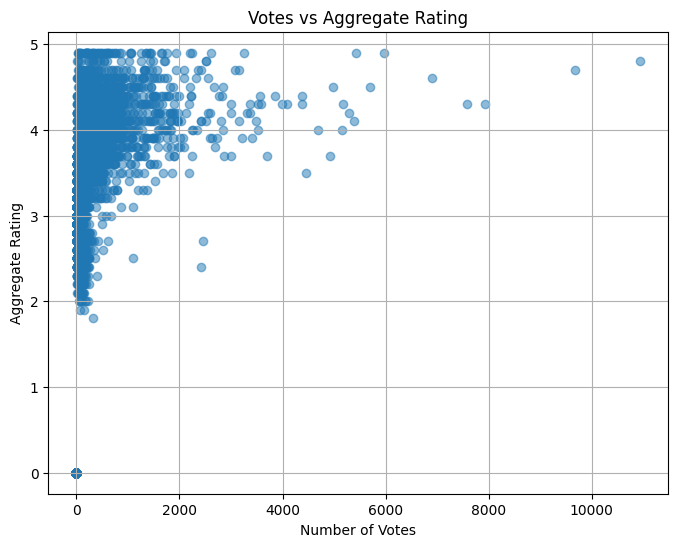

In [14]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Votes'], df['Aggregate rating'], alpha=0.5)
plt.title("Votes vs Aggregate Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")
plt.grid(True)
plt.show()

In [15]:
# Create a summary table
summary = {
    "Highest Votes": highest_votes['Votes'],
    "Lowest Votes": min_votes,
    "Correlation": round(correlation, 3)
}

print(summary)

{'Highest Votes': np.int64(10934), 'Lowest Votes': 0, 'Correlation': np.float64(0.314)}


**Level 3 task 3**

In [16]:
#the number of restaurants by price range and online delivery availability
online_delivery = pd.crosstab(df['Price range'], df['Has Online delivery'])

# Display the result
print("Price Range vs Online Delivery")
print(online_delivery)

Price Range vs Online Delivery
Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


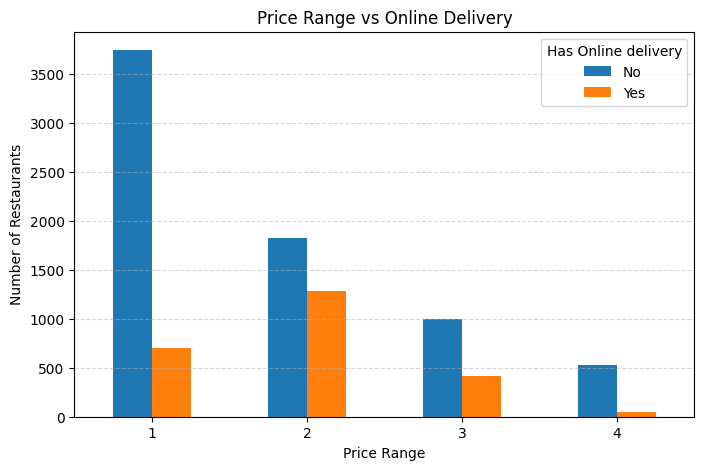

In [17]:
import matplotlib.pyplot as plt

# Create a bar chart
online_delivery.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Price Range vs Online Delivery")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [18]:
#the number of restaurants by price range and table booking availability
table_booking = pd.crosstab(df['Price range'], df['Has Table booking'])

# Display the result
print("Price Range vs Table Booking")
print(table_booking)

Price Range vs Table Booking
Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274


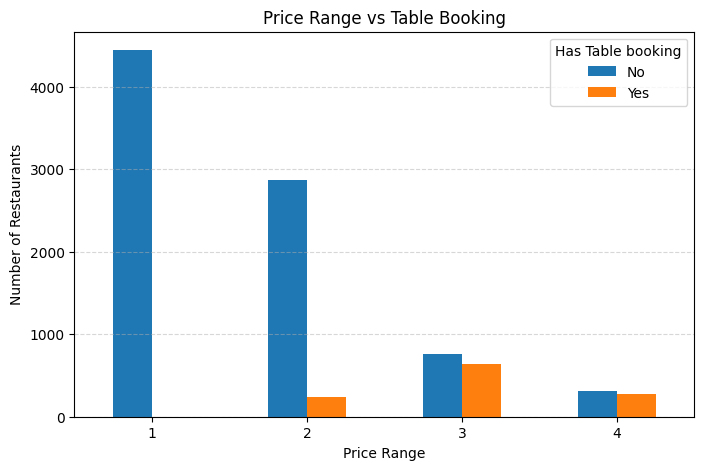

In [19]:
# Create a bar chart
table_booking.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Price Range vs Table Booking")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [20]:
#percentage distribution for online delivery
online_percentage = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'],
    normalize='index'
) * 100

# Display percentages
print(online_percentage.round(2))

Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04


In [21]:
#percentage distribution for table booking
table_percentage = pd.crosstab(
    df['Price range'],
    df['Has Table booking'],
    normalize='index'
) * 100

# Display percentages
print(table_percentage.round(2))

Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76


In [22]:
# Display summary tables
print("Online Delivery Percentage")
print(online_percentage.round(2))
print("\nTable Booking Percentage")
print(table_percentage.round(2))

Online Delivery Percentage
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04

Table Booking Percentage
Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76
